In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Utilities

In [2]:
!pip install timm
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.7 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report
import pydicom
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
import cv2
import ast
from torch.utils.data import Sampler
import random
import glob
import timm
import copy

In [4]:
class IPFDataLoader:
    """Carica e prepara i dati dal CSV"""

    def __init__(self, csv_path: str, csv_features_path : str,npy_dir:str):
        """
        Args:
            csv_path: Path al CSV con [Patient, Weeks, FVC, Slice_files, FVC slope, FVC intercept0]
            npy_dir: Directory path di file npy images

        """
        self.df = pd.read_csv(csv_path)
        self.npy_dir = npy_dir
        self.df_features = pd.read_csv(csv_features_path)

        print(f"✅ Loaded {len(self.df)} records from CSV")
        print(f"✅ Unique patients in CSV: {self.df['Patient'].nunique()}")
        print(f"✅ NPY directory: {npy_dir}")
        print(f"📋 Columns: {self.df.columns.tolist()}")

        # Verify demographic columns exist
        required_demo_cols = ['Age', 'Sex', 'SmokingStatus']
        missing_cols = [col for col in required_demo_cols if col not in self.df.columns]
        if missing_cols:
            print(f"⚠️  WARNING: Missing demographic columns: {missing_cols}")
        else:
            print(f"✅ All demographic columns present: {required_demo_cols}")

        # Verifica che i pazienti nel CSV abbiano cartelle NPY
        self._verify_npy_availability()

    def _verify_npy_availability(self):
        """Verifica che ogni paziente nel CSV abbia una cartella con file .npy"""
        patients_csv = set(self.df['Patient'].unique())
        patients_npy = set([d for d in os.listdir(self.npy_dir)
                           if os.path.isdir(os.path.join(self.npy_dir, d))])

        missing = patients_csv - patients_npy
        extra = patients_npy - patients_csv

        if missing:
            print(f"⚠️  {len(missing)} pazienti nel CSV senza cartella NPY: {list(missing)[:5]}...")
        if extra:
            print(f"ℹ️  {len(extra)} cartelle NPY non nel CSV (verranno ignorate)")

        available = patients_csv & patients_npy
        print(f"✅ {len(available)} pazienti con dati completi (CSV + NPY)")



    def get_patient_data(self) -> Dict[str, Dict]:
        """
        Organizza i dati per paziente

        Returns:
            {patient_id: {
                'slope': float,
                'intercept': float,
                'slices': [list_of_slice_paths],
                'weeks': [list_of_weeks],
                'fvc_values': [list_of_fvc]
            }}
        """
        patient_data = {}
        features_dict = {}

        for patient_id in self.df['Patient'].unique():
            patient_df = self.df[self.df['Patient'] == patient_id].sort_values('Weeks')
            patient_df_features = self.df_features[self.df_features['Patient'] == patient_id]

            # Slope e Intercept FVC (costanti per paziente)
            slope = patient_df['fvc_slope'].iloc[0]
            intercept = patient_df['fvc_intercept0'].iloc[0]

            #Get tabular data
            age = patient_df['Age'].iloc[0]
            sex = patient_df['Sex'].iloc[0]
            smoking_status = patient_df['SmokingStatus'].iloc[0]

            # Baseline (prima misurazione) -> Firstly use intercept a t=0
            #baseline_week = patient_df['Week'].iloc[0]
            #baseline_fvc = patient_df['FVC'].iloc[0]

            patient_npy_folder = os.path.join(self.npy_dir, patient_id)

            if not os.path.exists(patient_npy_folder):
                print(f"⚠️  Cartella NPY non trovata per {patient_id}, paziente saltato")
                continue

            # Ottieni tutti i file .npy ordinati
            npy_files = sorted(glob.glob(os.path.join(patient_npy_folder, "*.npy")))

            if not npy_files:
                print(f"⚠️  Nessun file NPY trovato per {patient_id}, paziente saltato")
                continue


            # Timeline completa
            weeks = patient_df['Weeks'].tolist()
            fvc_values = patient_df['FVC'].tolist()

            #Features
            ApproxVol_30_60 = float(patient_df_features['ApproxVol_30_60'].iloc[0])
            Avg_NumTissuePixel_30_60 = float(patient_df_features['Avg_NumTissuePixel_30_60'].iloc[0])
            Avg_Tissue_30_60 = float(patient_df_features['Avg_Tissue_30_60'].iloc[0])
            Avg_Tissue_thickness_30_60 = float(patient_df_features['Avg_Tissue_thickness_30_60'].iloc[0])
            Avg_TissueByTotal_30_60 = float(patient_df_features['Avg_TissueByTotal_30_60'].iloc[0])
            Avg_TissueByLung_30_60 = float(patient_df_features['Avg_TissueByLung_30_60'].iloc[0])
            Mean_30_60 = float(patient_df_features['Mean_30_60'].iloc[0])
            Skew_30_60 = float(patient_df_features['Skew_30_60'].iloc[0])
            Kurtosis_30_60 = float(patient_df_features['Kurtosis_30_60'].iloc[0])

            # ========================================
            # ENCODE CATEGORICAL FEATURES
            # ========================================

            # Sex: Male=1, Female=0
            sex_encoded = 1.0 if sex == 'Male' else 0.0

            # SmokingStatus: Ex-smoker=1, Never smoked=0, Currently smokes=2
            # (Adjust based on your actual categories)
            smoking_map = {
                'Ex-smoker': 1.0,
                'Never smoked': 0.0,
                'Currently smokes': 2.0,
            }
            smoking_encoded = smoking_map.get(smoking_status, 0.0)  # Default to 0 if unknown

            # Age: already numeric, just cast to float
            age_float = float(age)


            features_dict[patient_id] = {
                'approx_vol': ApproxVol_30_60,
                'avg_num_tissue_pixel' : Avg_NumTissuePixel_30_60,
                'avg_tissue': Avg_Tissue_30_60,
                'avg_tissue_thickness':Avg_Tissue_thickness_30_60,
                'avg_tissue_by_total': Avg_TissueByTotal_30_60,
                'avg_tissue_by_lung': Avg_TissueByLung_30_60,
                'mean' : Mean_30_60,
                'skew': Skew_30_60,
                'kurtosis': Kurtosis_30_60,
                # Demographic features (3) - NEWLY ADDED
                'age': age_float,
                'sex': sex_encoded,
                'smoking_status': smoking_encoded,
            }


            patient_data[patient_id] = {
                'slope': slope,
                'intercept': intercept,
                'slices': npy_files,
                'n_slices':len(npy_files),
                'weeks': weeks,
                'fvc_values': fvc_values
            }

        print(f"\n📊 Patient data prepared for {len(patient_data)} patients")

        # Statistiche sulle slice
        slice_counts = [data['n_slices'] for data in patient_data.values()]
        print(f"   Min slices: {min(slice_counts)}")
        print(f"   Max slices: {max(slice_counts)}")
        print(f"   Avg slices: {np.mean(slice_counts):.2f}")



        return patient_data,features_dict

    def split_patients(self, test_size=0.2, val_size=0.1, random_state=42):
        """
        Split a livello di PAZIENTE per evitare data leakage

        Returns:
            train_patients, val_patients, test_patients (liste di patient IDs)
        """
        # Solo pazienti che hanno sia dati CSV che cartella NPY
        patient_npy_folders = set([d for d in os.listdir(self.npy_dir)
                                   if os.path.isdir(os.path.join(self.npy_dir, d))])
        csv_patients = set(self.df['Patient'].unique())

        valid_patients = np.array(list(csv_patients & patient_npy_folders))

        print(f"\n🔄 Splitting {len(valid_patients)} valid patients...")

        # Prima split: Train+Val vs Test
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_val_idx, test_idx = next(splitter.split(valid_patients, groups=valid_patients))

        train_val_patients = valid_patients[train_val_idx]
        test_patients = valid_patients[test_idx]

        # Seconda split: Train vs Val
        val_size_adjusted = val_size / (1 - test_size)
        splitter = GroupShuffleSplit(n_splits=1, test_size=val_size_adjusted, random_state=random_state)
        train_idx, val_idx = next(splitter.split(train_val_patients, groups=train_val_patients))

        train_patients = train_val_patients[train_idx]
        val_patients = train_val_patients[val_idx]

        print(f"✅ Data Split:")
        print(f"   Train: {len(train_patients)} patients")
        print(f"   Val: {len(val_patients)} patients")
        print(f"   Test: {len(test_patients)} patients")

        return train_patients.tolist(), val_patients.tolist(), test_patients.tolist()




    def __len__(self):
        return len(self.df)



In [5]:
class IPFSliceDataset(Dataset):
    """Dataset che carica singole slice DICOM con slope come label"""

    def __init__(self, patient_list: List[str], patient_data: Dict,features_data:Dict,
                 transform=None, normalize_slope=True, image_size=(224, 224)):
        """
        Args:
            patient_list: Lista di patient IDs da includere (based on split)
            patient_data: Dict da IPFDataLoader.get_patient_data()
            transform: Trasformazioni immagini
            normalize_slope: Se normalizzare gli slope
            image_size: Dimensione target (H, W)
        """
        self.data = []
        self.slopes = []
        self.image_size = image_size
        self.transform = transform
        self._cache = {}

        # Crea lista (patient_id, slice_path, slope)
        for patient_id in patient_list:

            if patient_id not in patient_data:
                continue

            if patient_id not in features_data:
                continue

            #Extracts data from dictionary
            pdata = patient_data[patient_id]
            fdata = features_data[patient_id]
            #Slope
            slope = pdata['slope']

            slices = pdata['slices']
            weeks = pdata['weeks']

            for slice_path in slices:
              self.data.append({
                  'patient_id':patient_id,
                  'slice_path':slice_path,
                  'slope':float(slope),
                  'intercept':float(pdata.get('intercept',0.0)),
                  'features_patient':fdata
              })
              self.slopes.append(float(slope))

        #Mappa : paziente -> indice delle sue slices nel dataset

        self.patient_to_indices = defaultdict(list)
        for idx, item in enumerate(self.data):
          self.patient_to_indices[item['patient_id']].append(idx)
        self.patients = list(self.patient_to_indices.keys())

        print(f"Dataset created with {len(self.data)} slices from {len(patient_list)} patients")

        # Normalizzazione slope -> Try with both
        self.slope_scaler = None
        if normalize_slope and len(self.slopes) > 0:
            self.slope_scaler = StandardScaler()
            slopes_array = np.array(self.slopes).reshape(-1, 1)
            self.slope_scaler.fit(slopes_array)
            print(f"Slope normalization: mean={self.slope_scaler.mean_[0]:.2f}, std={self.slope_scaler.scale_[0]:.2f}")

    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):
        if idx in self._cache:
          return self._cache[idx]

        item = self.data[idx]

        try:
          # Carica NPY (già preprocessata: [224, 224] float32 normalizzata [0,1])
            img = np.load(item['slice_path'])

            # Verifica dimensioni
            if img.shape != (224, 224):
                raise ValueError(f"Unexpected shape: {img.shape}, expected (224, 224)")

            # Converti a 3 canali (RGB) se necessario
            # Se le tue NPY sono già [3, 224, 224], togli questa parte
            if img.ndim == 2:
                img = np.stack([img, img, img], axis=0)  # [3, 224, 224]

            # Applica trasformazioni aggiuntive se presenti
            if self.transform:
                img = self.transform(img)

            # Converti a tensor
            img_tensor = torch.FloatTensor(img)


        except Exception as e:
            print(f"⚠️  Error loading {item['slice_path']}: {e}")
            self._cache[idx] = None
            return None



        # Slope normalizzato
        slope = item['slope']
        if self.slope_scaler:
            slope = self.slope_scaler.transform([[slope]])[0][0]

        return {
            'image': img_tensor,
            'slope': torch.FloatTensor([slope]),
            'patient_id': item['patient_id'],
            'slice_path': item['slice_path'],
            'feature_patient': item['features_patient']
        }




# ============================================================
# UTILITY: COLLATE FUNCTION PER FILTRARE SLICE INVALIDE
# ============================================================

def collate_fn_filter_none(batch):
    """
    Collate function che filtra sample None (slice invalide).
    Utile se alcuni file NPY sono corrotti.
    """
    batch = [item for item in batch if item is not None]

    if len(batch) == 0:
        return None

    return torch.utils.data.dataloader.default_collate(batch)


In [6]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from torchvision import transforms

# ============================================================================
# FIX 1: IMPROVED PREPROCESSING WITH LUNG WINDOWING
# ============================================================================

class LungWindowTransform:
    """
    Apply proper lung windowing to CT images
    This enhances lung tissue and suppresses other structures
    """
    def __init__(self, window_center=-600, window_width=1500):
        """
        Standard lung window:
        - Center: -600 HU (air + lung tissue range)
        - Width: 1500 HU (captures full lung dynamic range)
        """
        self.wc = window_center
        self.ww = window_width
        self.wmin = self.wc - self.ww / 2
        self.wmax = self.wc + self.ww / 2

    def __call__(self, img):
        """
        Args:
            img: numpy array, assumed to be in HU units or normalized
        """
        # If already normalized [0,1], convert back to approximate HU
        if img.max() <= 1.0:
            # Assume original range was [-1000, 500] (typical CT)
            img = img * 1500 - 1000

        # Apply window
        img_windowed = np.clip(img, self.wmin, self.wmax)

        # Normalize to [0, 1]
        img_normalized = (img_windowed - self.wmin) / (self.wmax - self.wmin)

        return img_normalized


def create_lung_mask_attention(img, threshold=-500):
    """
    Create a soft mask emphasizing lung regions
    This can be used as attention guidance during training

    Args:
        img: (H, W) numpy array in HU units
        threshold: HU value to separate lung from other tissue

    Returns:
        mask: (H, W) soft attention mask [0, 1]
    """
    # Lung tissue is typically -900 to -500 HU
    # Soft tissue is > -100 HU

    # Create binary lung mask
    lung_mask = (img > -900) & (img < -500)

    # Dilate slightly to include peri-bronchial regions
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    lung_mask = cv2.dilate(lung_mask.astype(np.uint8), kernel, iterations=2)

    # Create soft mask with Gaussian blur
    soft_mask = cv2.GaussianBlur(lung_mask.astype(float), (15, 15), 0)

    # Normalize
    soft_mask = soft_mask / (soft_mask.max() + 1e-8)

    return soft_mask

In [7]:
# ============================================================================
# FIX 2: ATTENTION-GUIDED LOSS
# ============================================================================

class AttentionGuidedLoss(nn.Module):
    """
    Loss that penalizes attention on non-lung regions
    Encourages CNN to focus on relevant anatomy
    """
    def __init__(self, lung_mask_weight=0.1):
        super().__init__()
        self.lung_mask_weight = lung_mask_weight
        self.mse_loss = nn.MSELoss()

    def forward(self, predictions, targets, attention_maps, lung_masks):
        """
        Args:
            predictions: (batch,) predicted slopes
            targets: (batch,) true slopes
            attention_maps: (batch, H, W) attention from Grad-CAM or attention layer
            lung_masks: (batch, H, W) binary lung masks

        Returns:
            total_loss
        """
        # Standard prediction loss
        prediction_loss = self.mse_loss(predictions, targets)

        # Attention regularization: penalize attention outside lungs
        # attention_maps should sum to 1 per image
        attention_maps = attention_maps / (attention_maps.sum(dim=(1,2), keepdim=True) + 1e-8)

        # Compute attention inside vs outside lungs
        attention_inside = (attention_maps * lung_masks).sum(dim=(1,2))
        attention_outside = (attention_maps * (1 - lung_masks)).sum(dim=(1,2))

        # Penalize attention outside lungs
        attention_loss = attention_outside.mean()

        # Total loss
        total_loss = prediction_loss + self.lung_mask_weight * attention_loss

        return total_loss


In [8]:
# ============================================================================
# FIX 3: SPATIAL ATTENTION MODULE
# ============================================================================

class SpatialAttentionModule(nn.Module):
    """
    Explicit spatial attention that learns to focus on informative regions
    This is better than just relying on the CNN to learn implicitly
    """
    def __init__(self, in_channels):
        super().__init__()

        # Spatial attention pathway
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, kernel_size=1),
            nn.BatchNorm2d(in_channels // 8),
            nn.ReLU(),
            nn.Conv2d(in_channels // 8, 1, kernel_size=1),
            nn.Sigmoid()  # Output attention map [0, 1]
        )

    def forward(self, x):
        """
        Args:
            x: (B, C, H, W) feature map
        Returns:
            attended_x: (B, C, H, W) spatially weighted features
            attention_map: (B, 1, H, W) for visualization
        """
        attention_map = self.spatial_attention(x)  # (B, 1, H, W)
        attended_x = x * attention_map  # Element-wise multiplication

        return attended_x, attention_map


class ImprovedSliceLevelCNN(nn.Module):
    """
    CNN with explicit spatial attention
    Forces model to learn WHERE to look
    """
    def __init__(self, backbone_name='efficientnet_b0', pretrained=True):
        super().__init__()

        # Backbone
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            in_chans=3,
            num_classes=0,
            features_only=True  # Return intermediate features
        )

        # Get feature dimensions
        # For EfficientNet-B0: [16, 24, 40, 112, 1280]
        feat_dims = self.backbone.feature_info.channels()

        # Add spatial attention to last feature map
        self.spatial_attention = SpatialAttentionModule(feat_dims[-1])

        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # Prediction head
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(feat_dims[-1], 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x, return_attention=False):
        """
        Args:
            x: (B, 3, H, W) input images
            return_attention: if True, return attention maps for visualization
        """
        # Extract features
        features = self.backbone(x)
        last_feature_map = features[-1]  # (B, C, h, w)

        # Apply spatial attention
        attended_features, attention_map = self.spatial_attention(last_feature_map)

        # Global pooling
        pooled = self.global_pool(attended_features).flatten(1)  # (B, C)

        # Prediction
        output = self.head(pooled).squeeze(-1)  # (B,)

        if return_attention:
            return output, attention_map
        return output

In [9]:
# ============================================================================
# FIX 4: BETTER DATA AUGMENTATION
# ============================================================================

def get_lung_focused_augmentation():
    """
    Augmentation that preserves lung anatomy but varies appearance
    Helps model learn texture, not position
    """
    return transforms.Compose([
        # Geometric augmentation (mild, preserves anatomy)
        transforms.RandomRotation(degrees=10),  # Slight rotation
        transforms.RandomAffine(
            degrees=0,
            translate=(0.1, 0.1),  # 10% translation
            scale=(0.9, 1.1),  # 10% zoom
            shear=5  # Slight shear
        ),

        # Intensity augmentation (simulates scanner variations)
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=0.2,  # HU variations
                contrast=0.2,    # Window/level changes
            )
        ], p=0.7),

        # Add noise (simulates low-dose scans)
        transforms.RandomApply([
            transforms.Lambda(lambda x: x + torch.randn_like(x) * 0.02)
        ], p=0.5),

        # Random horizontal flip (lungs are symmetric)
        transforms.RandomHorizontalFlip(p=0.5),
    ])



In [10]:
class ImprovedSlopeTrainer:
    """
    Trainer with attention-guided loss and better monitoring
    """
    def __init__(self, model, device='cuda', use_attention_loss=False):
        self.model = model.to(device)
        self.device = device
        self.use_attention_loss = use_attention_loss

        # Losses
        self.criterion = nn.MSELoss()
        if use_attention_loss:
            self.attention_criterion = AttentionGuidedLoss(lung_mask_weight=0.1)

        self.optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-4,
            weight_decay=1e-5
        )

        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            patience=5,
            factor=0.5
        )

    # =========================================================================
    # TRAINING LOOP
    # =========================================================================
    def train_epoch(self, train_loader, lung_masks=None):

        self.model.train()
        total_loss = 0
        num_batches = 0

        for batch in train_loader:

            images = batch['images'].to(self.device)
            lengths = batch['lengths'].tolist()
            slopes = batch['slopes'].to(self.device)

            # Forward
            if self.use_attention_loss:
                preds_per_slice, attention_maps = self.model(images, return_attention=True)
            else:
                preds_per_slice = self.model(images)

            preds_per_slice = preds_per_slice.view(-1)

            # Aggregate per-patient
            pred_blocks = torch.split(preds_per_slice, lengths)
            slope_blocks = torch.split(slopes, lengths)

            patient_preds = torch.stack([blk.mean() for blk in pred_blocks])
            patient_slopes = torch.stack([blk[0] for blk in slope_blocks])

            # Loss
            loss = self.criterion(patient_preds, patient_slopes)

            # Backprop
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        return total_loss / num_batches

    # =========================================================================
    # VALIDATION LOOP — MATCHES TRAIN EPOCH
    # =========================================================================
    def validate(self, val_loader):

        self.model.eval()
        total_loss = 0.0
        num_batches = 0

        with torch.no_grad():
            for batch in val_loader:

                images = batch['images'].to(self.device)
                lengths = batch['lengths'].tolist()
                slopes = batch['slopes'].to(self.device)

                preds_per_slice = self.model(images).view(-1)

                # SAME AGGREGATION AS TRAINING
                pred_blocks = torch.split(preds_per_slice, lengths)
                slope_blocks = torch.split(slopes, lengths)

                patient_preds = torch.stack([blk.mean() for blk in pred_blocks])
                patient_slopes = torch.stack([blk[0] for blk in slope_blocks])

                loss = self.criterion(patient_preds, patient_slopes)
                total_loss += loss.item()
                num_batches += 1

        return total_loss / num_batches

    # =========================================================================
    # PREDICTION PER PATIENT — FIXED
    # =========================================================================
    def predict_per_patient(self, loader):

        self.model.eval()
        results = []

        with torch.no_grad():
            for batch in loader:

                images = batch['images'].to(self.device)
                lengths = batch['lengths'].tolist()
                slopes = batch['slopes']
                patient_ids = batch['patient_ids']
                features = batch['features']

                preds_per_slice = self.model(images).view(-1)
                pred_blocks = torch.split(preds_per_slice, lengths)

                # IMPORTANT — reset slice pointer before each batch
                start_slice = 0

                # Iterate patients in batch
                for i, pid in enumerate(patient_ids):

                    slope_pred = pred_blocks[i].mean().item()
                    true_slope = slopes[start_slice].item()

                    # Build row
                    row = {
                        "patient_id": pid,
                        "slope_cnn_mean": slope_pred,
                        "true_slope": true_slope
                    }

                    # add features (from first slice of this patient)
                    for fname, fvals in features.items():

                        row[fname] = float(fvals[start_slice])

                    results.append(row)

                    # move slice pointer
                    start_slice += lengths[i]

        return results


In [23]:
"""
COMPREHENSIVE MODEL COMPARISON FRAMEWORK
Compare 4 variants:
1. CNN-only
2. CNN + Demographics
3. CNN + Handcrafted Features
4. CNN + Demographics + Handcrafted Features
"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# =============================================================================
# FLEXIBLE SLOPE CORRECTOR (HANDLES VARIABLE FEATURES)
# =============================================================================

class FlexibleSlopeCorrector(nn.Module):
    """
    Corrector that adapts to different feature combinations
    """
    def __init__(self, input_dim, model_name="corrector"):
        super().__init__()
        self.model_name = model_name
        self.input_dim = input_dim

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        slope_cnn = x[:, 0:1]  # First feature is always CNN slope
        correction = self.mlp(x)
        final_slope = slope_cnn + correction
        return final_slope


# =============================================================================
# FEATURE BUILDER (CONSTRUCTS FEATURE VECTORS FOR EACH VARIANT)
# =============================================================================

class FeatureBuilder:
    """
    Builds feature vectors for different model variants
    """

    @staticmethod
    def get_cnn_only(slope_cnn):
        """
        Variant 1: CNN-only (no corrector needed)
        Returns: slope_cnn directly
        """
        return None  # Signal to use CNN prediction directly

    @staticmethod
    def get_demographics_only(slope_cnn, features_dict):
        """
        Variant 2: CNN + Demographics (3 features)
        Returns: [slope_cnn, age, sex, smoking_status]
        """
        return np.array([
            slope_cnn,
            features_dict['age'],
            features_dict['sex'],
            features_dict['smoking_status'],
        ], dtype=float)

    @staticmethod
    def get_handcrafted_only(slope_cnn, features_dict):
        """
        Variant 3: CNN + Handcrafted (9 features)
        Returns: [slope_cnn, approx_vol, ..., kurtosis]
        """
        return np.array([
            slope_cnn,
            features_dict['approx_vol'],
            features_dict['avg_num_tissue_pixel'],
            features_dict['avg_tissue'],
            features_dict['avg_tissue_thickness'],
            features_dict['avg_tissue_by_total'],
            features_dict['avg_tissue_by_lung'],
            features_dict['mean'],
            features_dict['skew'],
            features_dict['kurtosis'],
        ], dtype=float)

    @staticmethod
    def get_full_features(slope_cnn, features_dict):
        """
        Variant 4: CNN + Demographics + Handcrafted (12 features)
        Returns: [slope_cnn, demographics..., handcrafted...]
        """
        return np.array([
            slope_cnn,
            # Demographics
            features_dict['age'],
            features_dict['sex'],
            features_dict['smoking_status'],
            # Handcrafted
            features_dict['approx_vol'],
            features_dict['avg_num_tissue_pixel'],
            features_dict['avg_tissue'],
            features_dict['avg_tissue_thickness'],
            features_dict['avg_tissue_by_total'],
            features_dict['avg_tissue_by_lung'],
            features_dict['mean'],
            features_dict['skew'],
            features_dict['kurtosis'],
        ], dtype=float)


# =============================================================================
# MULTI-MODEL EVALUATOR
# =============================================================================

class MultiModelEvaluator:
    """
    Evaluates all 4 model variants on test set
    """

    def __init__(self, cnn_model, correctors_dict, scalers_dict,
                 patient_data, features_data, device='cuda'):
        """
        Args:
            cnn_model: Base CNN model
            correctors_dict: {
                'demographics': (corrector_model, scaler),
                'handcrafted': (corrector_model, scaler),
                'full': (corrector_model, scaler)
            }
            patient_data: Dict with slope, intercept, weeks, fvc_values
            features_data: Dict with all features
            device: cuda/cpu
        """
        self.cnn = cnn_model.to(device).eval()
        self.correctors = correctors_dict
        self.patient_data = patient_data
        self.features_data = features_data
        self.device = device

    def predict_slope(self, patient_id, test_ds, variant='cnn_only'):
      # -----------------------------
      # 1. CNN prediction (unchanged)
      # -----------------------------
      patient_indices = test_ds.patient_to_indices[patient_id]
      slopes_predicted = []

      with torch.no_grad():
          for idx in patient_indices:
              sample = test_ds[idx]
              if sample is None:
                  continue
              img = sample['image'].unsqueeze(0).to(self.device)
              slope_raw = self.cnn(img).cpu().item()
              slopes_predicted.append(slope_raw)

      if not slopes_predicted:
          return 0.0

      slope_cnn_mean = np.mean(slopes_predicted)

      # CNN-only → just denormalize and return
      if variant == 'cnn_only':
          if test_ds.slope_scaler:
              return test_ds.slope_scaler.inverse_transform([[slope_cnn_mean]])[0][0]
          return slope_cnn_mean

      # ---------------------------------------------
      # 2. Corrector-based variants (2, 3, 4)
      # ---------------------------------------------
      corrector, scaler, cols = self.correctors[variant]
      features_dict = self.features_data[patient_id]

      # === Variant 4: full features — MUST use training column order ===
      if variant == 'full':
          raw_dict = {
              'slope_cnn_mean': slope_cnn_mean,
              **features_dict
          }
          # Build vector in EXACT training order
          feature_vec = np.array([raw_dict[c] for c in cols], dtype=float)

      # === Variant 2: demographics only ===
      """
      elif variant == 'demographics':
          feature_vec = np.array([
              slope_cnn_mean,
              features_dict['age'],
              features_dict['sex'],
              features_dict['smoking_status']
          ], dtype=float)

      # === Variant 3: handcrafted only ===
      elif variant == 'handcrafted':
          feature_vec = np.array([
              slope_cnn_mean,
              features_dict['approx_vol'],
              features_dict['avg_num_tissue_pixel'],
              features_dict['avg_tissue'],
              features_dict['avg_tissue_thickness'],
              features_dict['avg_tissue_by_total'],
              features_dict['avg_tissue_by_lung'],
              features_dict['mean'],
              features_dict['skew'],
              features_dict['kurtosis'],
          ], dtype=float)
          """

      # Clean NaN
      feature_vec = np.nan_to_num(feature_vec, nan=0.0)

      # Scale
      feature_scaled = scaler.transform([feature_vec])

      feature_tensor = torch.tensor(feature_scaled, dtype=torch.float32).to(self.device)

      # Predict
      with torch.no_grad():
          slope_pred_norm = corrector(feature_tensor).cpu().item()

      # Denormalize
      if test_ds.slope_scaler:
          return test_ds.slope_scaler.inverse_transform([[slope_pred_norm]])[0][0]
      return slope_pred_norm


    def predict_fvc(self, patient_id, predicted_slope):
        """
        Predict FVC trajectory given slope

        Returns:
            weeks, predicted_fvc
        """
        pdata = self.patient_data[patient_id]
        weeks = np.array(pdata['weeks'])
        intercept = pdata['intercept']

        predicted_fvc = intercept + predicted_slope * weeks

        return weeks, predicted_fvc

    def evaluate_all_variants(self, test_ds, test_patients):
        """
        Evaluate all 4 variants on test set

        Returns:
            results_dict: {variant_name: {metrics, predictions_df}}
        """
        results = {}

        #variants = ['cnn_only', 'demographics', 'handcrafted', 'full']
        variants = ['cnn_only','full']
        """
        variant_names = {
            'cnn_only': 'CNN-only',
            'demographics': 'CNN + Demographics',
            'handcrafted': 'CNN + Handcrafted',
            'full': 'CNN + Demographics + Handcrafted'
        }
        """
        variant_names = {
            'cnn_only': 'CNN-only',
            'full': 'CNN + Demographics + Handcrafted'
        }

        for variant in variants:
            print(f"\n{'='*80}")
            print(f"Evaluating: {variant_names[variant]}")
            print(f"{'='*80}")

            predictions_list = []

            for patient_id in tqdm(test_patients, desc=f"Testing {variant}"):
                if patient_id not in self.patient_data:
                    continue

                # Predict slope
                pred_slope = self.predict_slope(patient_id, test_ds, variant=variant)
                true_slope = self.patient_data[patient_id]['slope']

                # Predict FVC trajectory
                weeks, pred_fvc = self.predict_fvc(patient_id, pred_slope)
                true_fvc = np.array(self.patient_data[patient_id]['fvc_values'])

                # Compute errors
                slope_error = abs(pred_slope - true_slope)
                fvc_errors = np.abs(pred_fvc - true_fvc)
                fvc_mae = fvc_errors.mean()

                predictions_list.append({
                    'patient_id': patient_id,
                    'pred_slope': pred_slope,
                    'true_slope': true_slope,
                    'slope_error': slope_error,
                    'fvc_mae': fvc_mae,
                    'n_timepoints': len(weeks)
                })

            # Aggregate metrics
            df = pd.DataFrame(predictions_list)

            metrics = {
                'variant': variant_names[variant],
                'slope_mae': df['slope_error'].mean(),
                'slope_rmse': np.sqrt((df['slope_error']**2).mean()),
                'fvc_mae': df['fvc_mae'].mean(),
                'fvc_rmse': np.sqrt((df['fvc_mae']**2).mean()),
                'n_patients': len(df)
            }

            print(f"\n📊 Results:")
            print(f"   Slope MAE: {metrics['slope_mae']:.4f} ml/week")
            print(f"   FVC MAE:   {metrics['fvc_mae']:.2f} ml")

            results[variant] = {
                'metrics': metrics,
                'predictions_df': df
            }

        return results


# =============================================================================
# VISUALIZATION SUITE
# =============================================================================

class ComparisonVisualizer:
    """
    Creates comprehensive comparison visualizations
    """

    @staticmethod
    def plot_performance_comparison(results_dict, save_path=None):
        """
        Bar charts comparing all 4 variants
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        """
        variants = ['cnn_only', 'demographics', 'handcrafted', 'full']
        variant_labels = ['CNN\nonly', 'CNN +\nDemo', 'CNN +\nHandcraft', 'CNN +\nBoth']
        colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
        """
        variants = ['cnn_only',  'full']
        variant_labels = ['CNN\nonly',  'CNN +\nBoth']
        colors = ['#3498db',  '#2ecc71']
        # Slope MAE
        slope_maes = [results_dict[v]['metrics']['slope_mae'] for v in variants]
        axes[0].bar(variant_labels, slope_maes, color=colors, alpha=0.8, edgecolor='black')
        axes[0].set_ylabel('Slope MAE (ml/week)', fontsize=12)
        axes[0].set_title('Slope Prediction Error', fontsize=14, fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)

        # Add values on bars
        for i, v in enumerate(slope_maes):
            axes[0].text(i, v + 0.1, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

        # FVC MAE
        fvc_maes = [results_dict[v]['metrics']['fvc_mae'] for v in variants]
        axes[1].bar(variant_labels, fvc_maes, color=colors, alpha=0.8, edgecolor='black')
        axes[1].set_ylabel('FVC MAE (ml)', fontsize=12)
        axes[1].set_title('FVC Prediction Error', fontsize=14, fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)

        # Add values on bars
        for i, v in enumerate(fvc_maes):
            axes[1].text(i, v + 3, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        # Print comparison table
        print("\n" + "="*80)
        print("PERFORMANCE COMPARISON TABLE")
        print("="*80)

        comparison_df = pd.DataFrame({
            'Model': [results_dict[v]['metrics']['variant'] for v in variants],
            'Slope MAE': slope_maes,
            'FVC MAE': fvc_maes,
        })

        print(comparison_df.to_string(index=False))

        # Compute improvements
        baseline = fvc_maes[0]  # CNN-only
        print(f"\n📈 Improvements vs CNN-only baseline ({baseline:.2f} ml):")
        for i, variant in enumerate(variants[1:], 1):
            diff = baseline - fvc_maes[i]
            pct = 100 * diff / baseline
            symbol = "✓" if diff > 0 else "✗"
            print(f"   {symbol} {results_dict[variants[i]]['metrics']['variant']}: "
                  f"{diff:+.2f} ml ({pct:+.1f}%)")

    @staticmethod
    def plot_patient_trajectories(evaluator, test_ds, patient_ids, save_path=None):
        """
        Plot FVC trajectories for sample patients with all 4 model predictions
        """
        n_patients = len(patient_ids)
        fig, axes = plt.subplots(n_patients, 1, figsize=(12, 5*n_patients))

        if n_patients == 1:
            axes = [axes]
        """
        variants = ['cnn_only', 'demographics', 'handcrafted', 'full']
        colors = {'cnn_only': '#3498db', 'demographics': '#e74c3c',
                  'handcrafted': '#f39c12', 'full': '#2ecc71'}
        labels = {'cnn_only': 'CNN-only', 'demographics': 'CNN + Demo',
                  'handcrafted': 'CNN + Handcraft', 'full': 'CNN + Both'}
                  """
        variants = ['cnn_only', 'full']
        colors = {'cnn_only': '#3498db',  'full': '#2ecc71'}
        labels = {'cnn_only': 'CNN-only', 'full': 'CNN + Both'}


        for idx, patient_id in enumerate(patient_ids):
            ax = axes[idx]

            # Get true trajectory
            pdata = evaluator.patient_data[patient_id]
            true_weeks = np.array(pdata['weeks'])
            true_fvc = np.array(pdata['fvc_values'])
            true_slope = pdata['slope']

            # Plot true FVC
            ax.scatter(true_weeks, true_fvc, s=100, color='black',
                      marker='o', label='True FVC', zorder=5)
            ax.plot(true_weeks, true_fvc, 'k--', alpha=0.3, linewidth=2)

            # Plot predictions from each variant
            for variant in variants:
                pred_slope = evaluator.predict_slope(patient_id, test_ds, variant=variant)
                weeks_pred, fvc_pred = evaluator.predict_fvc(patient_id, pred_slope)

                ax.plot(weeks_pred, fvc_pred, '-', linewidth=2.5,
                       color=colors[variant], label=labels[variant], alpha=0.8)

            # Formatting
            ax.set_xlabel('Weeks from Baseline', fontsize=12)
            ax.set_ylabel('FVC (ml)', fontsize=12)
            ax.set_title(f'Patient {patient_id}\n'
                        f'True Slope: {true_slope:.2f} ml/week',
                        fontsize=13, fontweight='bold')
            ax.legend(loc='best', framealpha=0.9)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_error_distributions(results_dict, save_path=None):
        """
        Violin plots showing error distributions for each variant
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        #variants = ['cnn_only', 'demographics', 'handcrafted', 'full']
        variants = ['cnn_only',  'full']

        # Prepare data for violin plots
        slope_data = []
        fvc_data = []
        variant_labels = []

        for variant in variants:
            df = results_dict[variant]['predictions_df']
            slope_data.append(df['slope_error'].values)
            fvc_data.append(df['fvc_mae'].values)
            variant_name = results_dict[variant]['metrics']['variant']
            variant_labels.append(variant_name.replace(' ', '\n'))

        # Slope errors
        parts1 = axes[0].violinplot(slope_data, positions=range(len(variants)),
                                     showmeans=True, showmedians=True)
        axes[0].set_xticks(range(len(variants)))
        axes[0].set_xticklabels(variant_labels, fontsize=10)
        axes[0].set_ylabel('Slope Error (ml/week)', fontsize=12)
        axes[0].set_title('Slope Error Distribution', fontsize=14, fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)

        # FVC errors
        parts2 = axes[1].violinplot(fvc_data, positions=range(len(variants)),
                                     showmeans=True, showmedians=True)
        axes[1].set_xticks(range(len(variants)))
        axes[1].set_xticklabels(variant_labels, fontsize=10)
        axes[1].set_ylabel('FVC MAE per patient (ml)', fontsize=12)
        axes[1].set_title('FVC Error Distribution', fontsize=14, fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()


# =============================================================================
# MAIN COMPARISON PIPELINE
# =============================================================================

def run_comprehensive_comparison(
    cnn_model,
    test_ds,
    test_patients,
    patient_data,
    features_data,
    correctors_dict,  # {'demographics': (model, scaler), 'handcrafted': ..., 'full': ...}
    device='cuda',
    save_dir='./comparison_results'
):
    """
    Run complete comparison of all 4 variants

    Args:
        cnn_model: Trained CNN
        test_ds: Test dataset
        test_patients: List of test patient IDs
        patient_data: Dict with patient info
        features_data: Dict with features
        correctors_dict: Dict of trained correctors
        device: cuda/cpu
        save_dir: Where to save results

    Returns:
        results_dict: Complete results for all variants
    """

    os.makedirs(save_dir, exist_ok=True)

    print("\n" + "="*80)
    print("COMPREHENSIVE MODEL COMPARISON")
    print("="*80)
    print(f"\nComparing 4 variants:")
    print("  1. CNN-only (baseline)")
    #print("  2. CNN + Demographics (age, sex, smoking)")
    #print("  3. CNN + Handcrafted Features (9 mask-based)")
    print("  4. CNN + Demographics + Handcrafted (all 12)")

    # Initialize evaluator
    evaluator = MultiModelEvaluator(
        cnn_model, correctors_dict, {},
        patient_data, features_data, device
    )

    # Evaluate all variants
    results_dict = evaluator.evaluate_all_variants(test_ds, test_patients)

    # Visualizations
    print("\n" + "="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)

    # 1. Performance comparison
    ComparisonVisualizer.plot_performance_comparison(
        results_dict,
        save_path=os.path.join(save_dir, 'performance_comparison.png')
    )

    # 2. Error distributions
    ComparisonVisualizer.plot_error_distributions(
        results_dict,
        save_path=os.path.join(save_dir, 'error_distributions.png')
    )

    # 3. Sample patient trajectories (select 3 diverse patients)
    # Pick patients with different progression rates
    sample_patients = select_diverse_patients(patient_data, test_patients, n=3)

    ComparisonVisualizer.plot_patient_trajectories(
        evaluator, test_ds, sample_patients,
        save_path=os.path.join(save_dir, 'patient_trajectories.png')
    )

    # Save detailed results
    for variant in results_dict:
        df = results_dict[variant]['predictions_df']
        df.to_csv(os.path.join(save_dir, f'{variant}_predictions.csv'), index=False)

    # Save summary
    summary = {
        variant: results_dict[variant]['metrics']
        for variant in results_dict
    }

    import json
    with open(os.path.join(save_dir, 'comparison_summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)

    print(f"\n✅ All results saved to: {save_dir}")

    return results_dict


def select_diverse_patients(patient_data, patient_list, n=3):
    """
    Select n patients with diverse progression patterns
    """
    slopes = [(pid, patient_data[pid]['slope']) for pid in patient_list
              if pid in patient_data]
    slopes.sort(key=lambda x: x[1])

    # Pick: most declining, stable, improving
    indices = [0, len(slopes)//2, -1]
    selected = [slopes[i][0] for i in indices[:n]]

    return selected


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    """
    # Example usage in your notebook:

    # 1. Train CNN (already done)
    cnn_model = SliceLevelCNN(...)

    # 2. Train 3 correctors (one for each variant)
    # ... (train demographics corrector)
    # ... (train handcrafted corrector)
    # ... (train full corrector)

    correctors_dict = {
        'demographics': (demo_corrector, demo_scaler),
        'handcrafted': (handcraft_corrector, handcraft_scaler),
        'full': (full_corrector, full_scaler)
    }

    # 3. Run comprehensive comparison
    results = run_comprehensive_comparison(
        cnn_model=cnn_model,
        test_ds=test_ds,
        test_patients=test_patients,
        patient_data=patient_data,
        features_data=features_data,
        correctors_dict=correctors_dict,
        device='cuda',
        save_dir='./comparison_results'
    )
    """
    pass

In [12]:
def build_dataframe(patient_rows, feature_order = None):
    """Build dataframe from patient predictions - handles dynamic features"""
    df = pd.DataFrame(patient_rows)
    df = df.drop_duplicates(subset=["patient_id"])
    # If explicit order provided, reorder columns
    if feature_order is not None:
        # Verify all required columns exist
        missing = [c for c in feature_order if c not in df.columns]
        if missing:
            print(f"⚠️  WARNING: Missing columns: {missing}")

        # Reorder: specified columns + any extras
        other_cols = [c for c in df.columns if c not in feature_order]
        df = df[feature_order + other_cols]

    print(f"DataFrame columns: {list(df.columns)}")

    return df


def normalize_df(df, scaler=None, feature_cols=None):
    """
    Normalize all features with EXPLICIT column order
    """
    exclude = ["patient_id", "true_slope"]

    if feature_cols is None:
        feature_cols = [c for c in df.columns if c not in exclude]
        print("⚠️  WARNING: No explicit feature order provided!")

    # Verify columns exist
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Extract in ORDER
    X = df[feature_cols].values

    if scaler is None:
        print(f"\n{'='*70}")
        print("RAW FEATURE STATISTICS:")
        print(f"{'='*70}")
        for i, col in enumerate(feature_cols):
            print(f"{col:25s}: mean={X[:, i].mean():12.2f}, std={X[:, i].std():12.2f}")
        print(f"{'='*70}\n")

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)

    df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)
    df_scaled["patient_id"] = df["patient_id"].values
    df_scaled["true_slope"] = df["true_slope"].values

    return df_scaled, scaler, feature_cols

In [13]:
def build_feature_vectors(features_data):
    feat_dict = {}
    for pid, f in features_data.items():
        feat_vec = np.array([
            f['approx_vol'],
            f['avg_num_tissue_pixel'],
            f['avg_tissue'],
            f['avg_tissue_thickness'],
            f['avg_tissue_by_total'],
            f['avg_tissue_by_lung'],
            f['mean'],
            f['skew'],
            f['kurtosis'],
            f['age'],
            f['sex'],
            f['smoking_status'],
            f['age'],
            f['sex'],
            f['smoking_status']
        ], dtype=float)
        feat_dict[pid] = feat_vec
    return feat_dict


In [42]:
class SlopeCorrector(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.10),   # ↓ molto più basso

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.05),   # ↓ molto più basso

            nn.Linear(16, 1)
        )

    def forward(self, x):
        base = x[:, 0:1]      # slope_cnn_mean
        corr = self.mlp(x)
        return base + corr


In [48]:
def train_slope_corrector(df_train, df_val, feature_cols, device):
    """Train corrector - automatically uses correct input_dim"""

    X_train = torch.tensor(df_train[feature_cols].values, dtype=torch.float32).to(device)
    y_train = torch.tensor(df_train["true_slope"].values, dtype=torch.float32).unsqueeze(1).to(device)

    X_val = torch.tensor(df_val[feature_cols].values, dtype=torch.float32).to(device)
    y_val = torch.tensor(df_val["true_slope"].values, dtype=torch.float32).unsqueeze(1).to(device)

    # Corrector with correct input dim (13 features)
    corrector = SlopeCorrector(input_dim=len(feature_cols)).to(device)
    optimizer = torch.optim.Adam(
        corrector.parameters(),
        lr=5e-4,weight_decay=5e-3
    )
    criterion = torch.nn.L1Loss()


    best_val = float("inf")
    best_state = None

    print(f"\n🔧 Training corrector with {len(feature_cols)} features:")
    print(f"   Features: {feature_cols}")

    for epoch in range(180):
        corrector.train()
        pred = corrector(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        corrector.eval()
        with torch.no_grad():
            pred_val = corrector(X_val)
            val_loss = criterion(pred_val, y_val).item()

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(corrector.state_dict())

        if epoch % 5 == 0:
            print(f"[Corrector] Epoch {epoch+1:02d} | Train={loss.item():.4f} | Val={val_loss:.4f}")

    corrector.load_state_dict(best_state)
    print(f"✅ Best validation loss: {best_val:.4f}")

    return corrector, best_val

In [16]:
class PatientBatchSampler(Sampler):
  def __init__(self,dataset,patients_per_batch=4,shuffle=True):
    self.ds = dataset
    self.shuffle = shuffle
    self.ppb =patients_per_batch

  def __iter__(self):
    patients = list(self.ds.patients)
    if self.shuffle:
      random.shuffle(patients)

    for i in range(0,len(patients),self.ppb):
      batch_pids = patients[i:i+self.ppb]
      idxs = []
      for pid in batch_pids:
        pidxs = list(self.ds.patient_to_indices[pid])
        idxs.extend(pidxs)
      yield idxs

  def __len__(self):
    from math import ceil
    return (len(self.ds.patients)+self.ppb -1) // self.ppb


def patient_group_collate(batch):

    # Filtra elementi None
    batch = [b for b in batch if b is not None]

    if len(batch) == 0:
        return {
            'images': torch.empty(0, 3, 224, 224),
            'slopes': torch.empty(0),
            'patient_ids': [],
            'lengths': torch.empty(0, dtype=torch.long),
            'slice_paths': [],
            'features': { }  # dizionario vuoto
        }

    # Estrai tensori
    images = torch.stack([b['image'] for b in batch])
    slopes = torch.stack([b['slope'] for b in batch]).view(-1)
    slice_paths = [b['slice_path'] for b in batch]

    # Feature per slice (dict of lists)
    features_dict = {k: [] for k in batch[0]['feature_patient'].keys()}
    for b in batch:
        for k, v in b['feature_patient'].items():
            features_dict[k].append(v)

    # Group slices by patient
    lengths, pid_order = [], []
    i = 0
    while i < len(batch):
        pid = batch[i]['patient_id']
        j = i
        while j < len(batch) and batch[j]['patient_id'] == pid:
            j += 1
        lengths.append(j - i)
        pid_order.append(pid)
        i = j

    return {
        'images': images,
        'slopes': slopes,
        'patient_ids': pid_order,
        'lengths': torch.tensor(lengths, dtype=torch.long),
        'slice_paths': slice_paths,
        'features': features_dict
    }



# 4 VARIANTS - TRAINING SCRIPT

In [17]:
# =============================================================================
# STEP 1: CONFIGURATION
# =============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON SETUP WITH VALIDATION")
print("="*80)

# Paths
CSV_PATH = '/content/drive/MyDrive/Training FVC Linear/train_with_coefs.csv'
CSV_FEATURES_PATH = '/content/drive/MyDrive/patient_features.csv'
NPY_DIR = '/content/drive/MyDrive/npy_files/extracted_npy'
CHECKPOINT_DIR = "/content/drive/MyDrive/Training FVC Linear/model_comparison"

# Hyperparameters
IMAGE_SIZE = (224, 224)
PATIENTS_PER_BATCH = 4
RANDOM_SEED = 42

# At the top of your training script
FULL_FEATURE_ORDER = [
    'patient_id',
    'slope_cnn_mean',
    'age',
    'sex',
    'smoking_status',
    'approx_vol',
    'avg_num_tissue_pixel',
    'avg_tissue',
    'avg_tissue_thickness',
    'avg_tissue_by_total',
    'avg_tissue_by_lung',
    'mean',
    'skew',
    'kurtosis',
    'true_slope',
]

# Define feature columns (exclude patient_id and true_slope)
FULL_FEATURE_COLS = [
    'slope_cnn_mean',
    'age',
    'sex',
    'smoking_status',
    'approx_vol',
    'avg_num_tissue_pixel',
    'avg_tissue',
    'avg_tissue_thickness',
    'avg_tissue_by_total',
    'avg_tissue_by_lung',
    'mean',
    'skew',
    'kurtosis',
]

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Using device: {device}")

# =============================================================================
# STEP 2: LOAD DATA
# =============================================================================

print("\n" + "="*80)
print("[1/10] LOADING DATA")
print("="*80)

dl = IPFDataLoader(CSV_PATH, CSV_FEATURES_PATH, NPY_DIR)
patient_data, features_data = dl.get_patient_data()

print(f"\n✓ Loaded patient_data for {len(patient_data)} patients")
print(f"✓ Loaded features_data for {len(features_data)} patients")

# Verify data structure
sample_patient = list(patient_data.keys())[0]
print(f"\n📋 Sample patient data structure (ID: {sample_patient}):")
for key, value in patient_data[sample_patient].items():
    if isinstance(value, list):
        print(f"   {key}: list with {len(value)} items")
    else:
        print(f"   {key}: {type(value).__name__} = {value}")

print(f"\n📋 Sample feature data structure:")
for key, value in features_data[sample_patient].items():
    print(f"   {key}: {value:.2f}" if isinstance(value, float) else f"   {key}: {value}")

# =============================================================================
# STEP 3: TRAIN/TEST SPLIT
# =============================================================================

print("\n" + "="*80)
print("[2/10] CREATING TRAIN/TEST SPLIT")
print("="*80)

all_patients = list(patient_data.keys())
print(f"\n✓ Total patients available: {len(all_patients)}")

# Recreate exact same split as training
np.random.seed(RANDOM_SEED)
np.random.shuffle(all_patients)

test_size = int(len(all_patients) * 0.2)
test_patients = all_patients[:test_size]
train_patients = all_patients[test_size:]

print(f"✓ Train patients: {len(train_patients)}")
print(f"✓ Test patients:  {len(test_patients)}")
print(f"\n📝 First 5 test patients: {test_patients[:5]}")
print(f"📝 First 5 train patients: {train_patients[:5]}")

# Verify no overlap
overlap = set(train_patients) & set(test_patients)
if overlap:
    print(f"❌ ERROR: {len(overlap)} patients in both train and test!")
else:
    print(f"✓ No patient overlap between train and test")

# =============================================================================
# STEP 4: CREATE DATASETS
# =============================================================================

print("\n" + "="*80)
print("[3/10] CREATING DATASETS")
print("="*80)

train_ds = IPFSliceDataset(
    train_patients,
    patient_data,
    features_data,
    normalize_slope=True,
    image_size=IMAGE_SIZE
)

print(f"\n✓ Train dataset created:")
print(f"   Total slices: {len(train_ds)}")
print(f"   Patients: {len(train_ds.patients)}")
print(f"   Slope scaler fitted: {train_ds.slope_scaler is not None}")

test_ds = IPFSliceDataset(
    test_patients,
    patient_data,
    features_data,
    normalize_slope=True,
    image_size=IMAGE_SIZE
)
test_ds.slope_scaler = train_ds.slope_scaler

print(f"\n✓ Test dataset created:")
print(f"   Total slices: {len(test_ds)}")
print(f"   Patients: {len(test_ds.patients)}")

# Verify slope scaler
if train_ds.slope_scaler:
    print(f"\n📊 Slope normalization:")
    print(f"   Mean: {train_ds.slope_scaler.mean_[0]:.2f} ml/week")
    print(f"   Std:  {train_ds.slope_scaler.scale_[0]:.2f} ml/week")

    # Test denormalization
    test_norm = np.array([[0.0]])
    test_denorm = train_ds.slope_scaler.inverse_transform(test_norm)[0][0]
    print(f"   Test: normalized=0.0 → denormalized={test_denorm:.2f}")

# Sample a few items to verify loading
print(f"\n🔍 Testing dataset loading (3 random samples)...")
for i in np.random.choice(len(test_ds), 3, replace=False):
    sample = test_ds[i]
    if sample is not None:
        print(f"   ✓ Sample {i}: image shape={sample['image'].shape}, "
              f"slope={sample['slope'].item():.3f}, patient={sample['patient_id'][:10]}...")
    else:
        print(f"   ❌ Sample {i}: Failed to load")

# =============================================================================
# STEP 5: CREATE DATALOADERS
# =============================================================================

print("\n" + "="*80)
print("[4/10] CREATING DATALOADERS")
print("="*80)

train_loader = DataLoader(
        train_ds,
        batch_sampler=PatientBatchSampler(
            train_ds,
            patients_per_batch=PATIENTS_PER_BATCH,
            shuffle=True  # ✓ Shuffle for training
        ),
        collate_fn=patient_group_collate,
        num_workers=4,
        pin_memory=True
    )

test_loader = DataLoader(
    test_ds,
    batch_sampler=PatientBatchSampler(
        test_ds,
        patients_per_batch=PATIENTS_PER_BATCH,
        shuffle=False
    ),
    collate_fn=patient_group_collate,
    num_workers=4,
    pin_memory=True
)

print(f"\n✓ Test loader created:")
print(f"   Total batches: {len(test_loader)}")
print(f"   Patients per batch: {PATIENTS_PER_BATCH}")

# Test loading one batch
print(f"\n🔍 Testing batch loading...")
try:
    test_batch = next(iter(test_loader))
    print(f"   ✓ Batch loaded successfully")
    print(f"   Images shape: {test_batch['images'].shape}")
    print(f"   Slopes shape: {test_batch['slopes'].shape}")
    print(f"   Patients in batch: {len(test_batch['patient_ids'])}")
    print(f"   Patient IDs: {test_batch['patient_ids']}")
    print(f"   Lengths: {test_batch['lengths'].tolist()}")
except Exception as e:
    print(f"   ❌ Error loading batch: {e}")



MODEL COMPARISON SETUP WITH VALIDATION
✓ Using device: cuda

[1/10] LOADING DATA
✅ Loaded 1549 records from CSV
✅ Unique patients in CSV: 176
✅ NPY directory: /content/drive/MyDrive/npy_files/extracted_npy
📋 Columns: ['Patient', 'Weeks', 'FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus', 'slice_files', 'fvc_slope', 'fvc_intercept0']
✅ All demographic columns present: ['Age', 'Sex', 'SmokingStatus']
✅ 176 pazienti con dati completi (CSV + NPY)

📊 Patient data prepared for 176 patients
   Min slices: 4
   Max slices: 11
   Avg slices: 10.20

✓ Loaded patient_data for 176 patients
✓ Loaded features_data for 176 patients

📋 Sample patient data structure (ID: ID00007637202177411956430):
   slope: float64 = -3.1671258700696137
   intercept: float64 = 2174.416183294663
   slices: list with 9 items
   n_slices: int = 9
   weeks: list with 9 items
   fvc_values: list with 9 items

📋 Sample feature data structure:
   approx_vol: 445808.63
   avg_num_tissue_pixel: 8707.60
   avg_tissue: 5680.35
  

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


   ✓ Batch loaded successfully
   Images shape: torch.Size([39, 3, 224, 224])
   Slopes shape: torch.Size([39])
   Patients in batch: 4
   Patient IDs: ['ID00048637202185016727717', 'ID00110637202210673668310', 'ID00339637202287377736231', 'ID00076637202199015035026']
   Lengths: [6, 11, 11, 11]


In [18]:

# =============================================================================
# STEP 3 - LOAD CNN MODEL
# =============================================================================
cnn_model = ImprovedSliceLevelCNN(backbone_name='efficientnet_b0', pretrained=False)

state_dict = torch.load('/content/drive/MyDrive/Training FVC Linear/checkpoints_kfold_added_hf_tabular_attention_adj_lr/cnn_final.pth', map_location='cpu')
cnn_model.load_state_dict(state_dict)

cnn_model.to(device)
cnn_model.eval()

print("Model loaded successfully.")


Model loaded successfully.



[1/4] Generating CNN predictions for training set...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


DataFrame columns: ['patient_id', 'slope_cnn_mean', 'age', 'sex', 'smoking_status', 'approx_vol', 'avg_num_tissue_pixel', 'avg_tissue', 'avg_tissue_thickness', 'avg_tissue_by_total', 'avg_tissue_by_lung', 'mean', 'skew', 'kurtosis', 'true_slope']
✓ Generated predictions for 141 patients
✓ Features available: ['patient_id', 'slope_cnn_mean', 'age', 'sex', 'smoking_status', 'approx_vol', 'avg_num_tissue_pixel', 'avg_tissue', 'avg_tissue_thickness', 'avg_tissue_by_total', 'avg_tissue_by_lung', 'mean', 'skew', 'kurtosis', 'true_slope']

[2/5] Checking for NaN values...
   ⚠️  mean: 2 NaN values (1.4%)
   ⚠️  skew: 2 NaN values (1.4%)
   ⚠️  kurtosis: 2 NaN values (1.4%)

⚠️  Found NaN in 3 features
   Applying mean imputation...
   ✓ mean: Imputing with mean=89.1588
   ✓ skew: Imputing with mean=1.1783
   ✓ kurtosis: Imputing with mean=1.3464

✓ All NaN values handled successfully

[2/4] Preparing feature sets for 3 variants...
✓ Full features: 13

[3/4] Creating train/val splits...
✓ Trai

/tmp/ipython-input-3134596238.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_full[col].fillna(mean_val, inplace=True)


[Corrector] Epoch 21 | Train=0.4238 | Val=0.3956
[Corrector] Epoch 26 | Train=0.4304 | Val=0.3940
[Corrector] Epoch 31 | Train=0.4222 | Val=0.3927
[Corrector] Epoch 36 | Train=0.4108 | Val=0.3914
[Corrector] Epoch 41 | Train=0.3989 | Val=0.3897
[Corrector] Epoch 46 | Train=0.3957 | Val=0.3880
[Corrector] Epoch 51 | Train=0.3923 | Val=0.3868
[Corrector] Epoch 56 | Train=0.3944 | Val=0.3856
[Corrector] Epoch 61 | Train=0.3879 | Val=0.3836
[Corrector] Epoch 66 | Train=0.3747 | Val=0.3811
[Corrector] Epoch 71 | Train=0.3796 | Val=0.3786
[Corrector] Epoch 76 | Train=0.3827 | Val=0.3762
[Corrector] Epoch 81 | Train=0.3653 | Val=0.3743
[Corrector] Epoch 86 | Train=0.3719 | Val=0.3720
[Corrector] Epoch 91 | Train=0.3722 | Val=0.3695
[Corrector] Epoch 96 | Train=0.3567 | Val=0.3663
[Corrector] Epoch 101 | Train=0.3547 | Val=0.3636
[Corrector] Epoch 106 | Train=0.3553 | Val=0.3614
[Corrector] Epoch 111 | Train=0.3487 | Val=0.3587
[Corrector] Epoch 116 | Train=0.3574 | Val=0.3568
[Corrector] Epoc

Testing cnn_only: 100%|██████████| 35/35 [00:04<00:00,  7.35it/s]



📊 Results:
   Slope MAE: 3.6393 ml/week
   FVC MAE:   128.38 ml

Evaluating: CNN + Demographics + Handcrafted


Testing full: 100%|██████████| 35/35 [00:04<00:00,  7.61it/s]



📊 Results:
   Slope MAE: 2.7323 ml/week
   FVC MAE:   110.67 ml

GENERATING VISUALIZATIONS


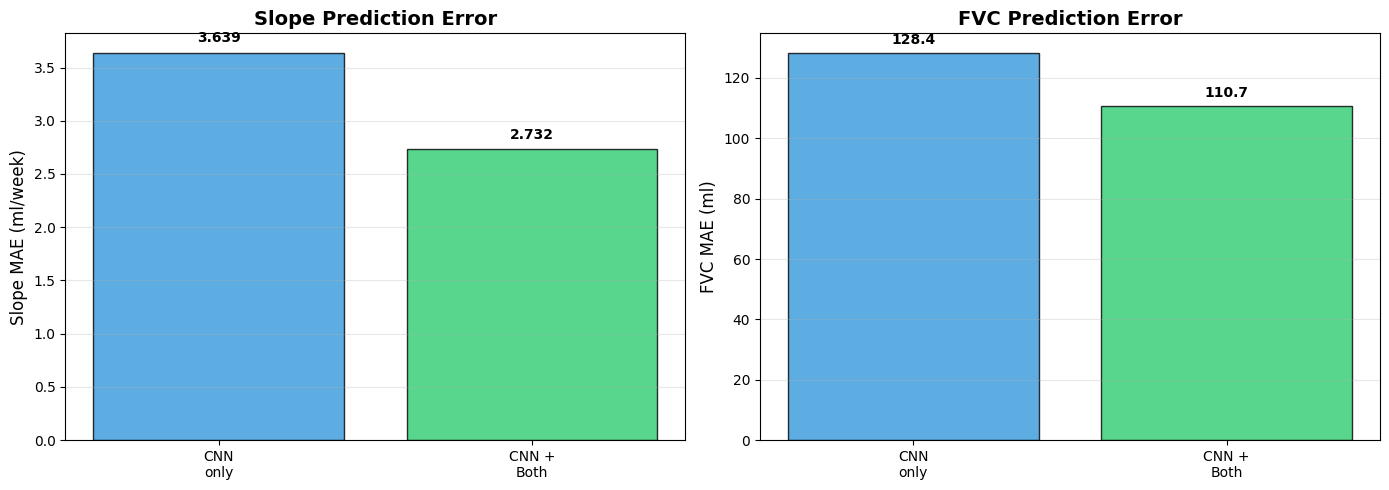


PERFORMANCE COMPARISON TABLE
                           Model  Slope MAE    FVC MAE
                        CNN-only   3.639325 128.380227
CNN + Demographics + Handcrafted   2.732269 110.668298

📈 Improvements vs CNN-only baseline (128.38 ml):
   ✓ CNN + Demographics + Handcrafted: +17.71 ml (+13.8%)


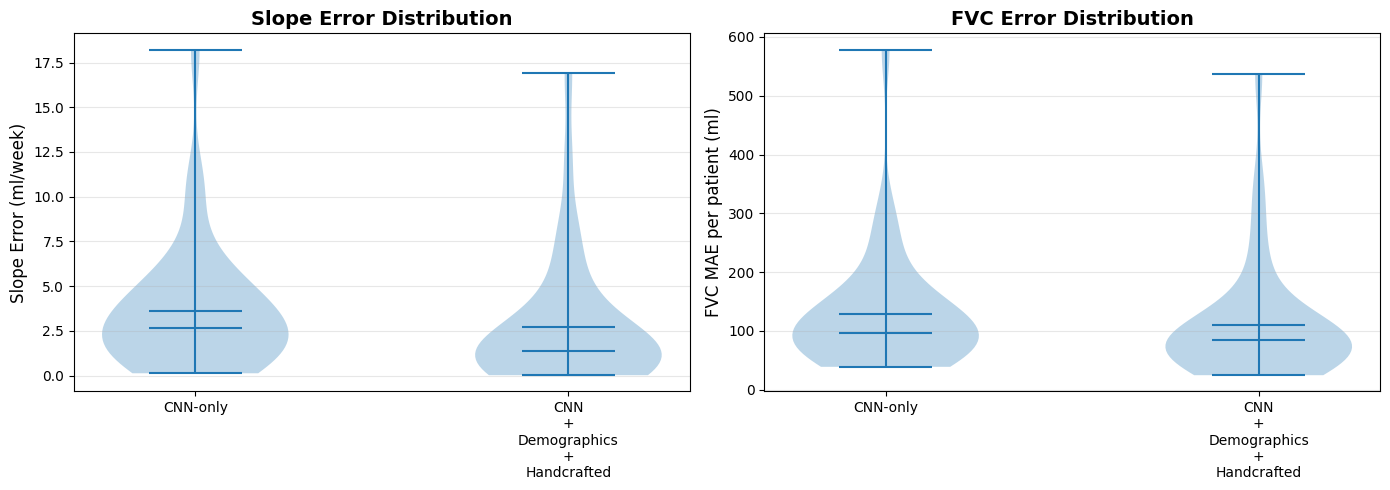

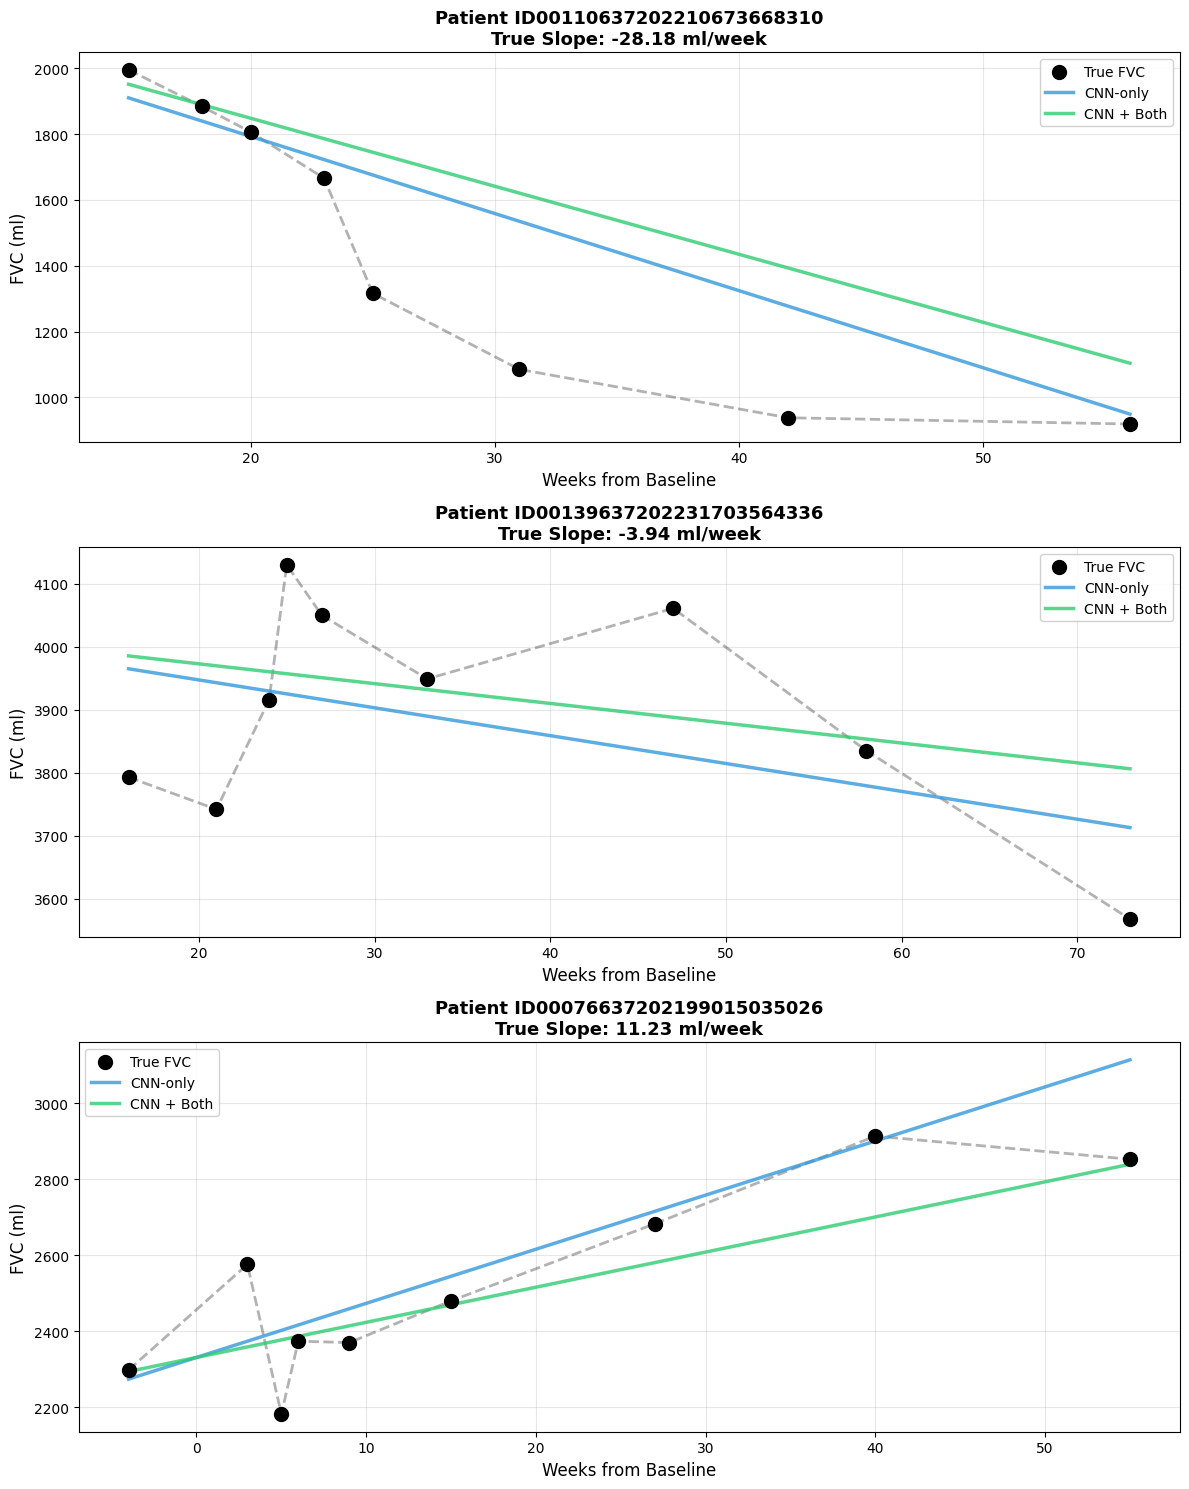


✅ All results saved to: ./comparison_results_full_bf_progresspred_final

FINAL RESULTS SUMMARY

📊 FVC MAE Comparison:
   1. CNN-only:              128.38 ml (baseline)
   4. CNN + Both:            110.67 ml (-17.71 ml)

🏆 Best Model: CNN + Demographics + Handcrafted
   FVC MAE: 110.67 ml
   Improvement vs baseline: 17.71 ml (13.8%)

COMPARISON COMPLETE!

📁 Results saved to: ./comparison_results/
   - performance_comparison.png
   - error_distributions.png
   - patient_trajectories.png
   - comparison_summary.json
   - *_predictions.csv (detailed results)


In [49]:

# =============================================================================
# STEP 2: GENERATE PREDICTIONS FROM CNN
# =============================================================================

print("\n[1/4] Generating CNN predictions for training set...")

trainer = ImprovedSlopeTrainer(cnn_model)
patient_rows = trainer.predict_per_patient(train_loader)
df_full = build_dataframe(patient_rows, feature_order=FULL_FEATURE_ORDER)

print(f"✓ Generated predictions for {len(df_full)} patients")
print(f"✓ Features available: {df_full.columns.tolist()}")

# =============================================================================
# STEP 2.5: CHECK AND HANDLE NaN VALUES
# =============================================================================

print("\n[2/5] Checking for NaN values...")

# Check each feature column for NaN
feature_cols = [c for c in df_full.columns if c not in ['patient_id', 'true_slope']]
nan_summary = {}

for col in feature_cols:
    n_nan = df_full[col].isna().sum()
    if n_nan > 0:
        nan_summary[col] = n_nan
        print(f"   ⚠️  {col}: {n_nan} NaN values ({100*n_nan/len(df_full):.1f}%)")

if nan_summary:
    print(f"\n⚠️  Found NaN in {len(nan_summary)} features")
    print("   Applying mean imputation...")

    # Impute NaN with mean for each feature
    for col in nan_summary.keys():
        mean_val = df_full[col].mean()
        if pd.isna(mean_val):  # All values are NaN
            print(f"   ⚠️  {col}: All values are NaN, filling with 0")
            df_full[col].fillna(0, inplace=True)
        else:
            print(f"   ✓ {col}: Imputing with mean={mean_val:.4f}")
            df_full[col].fillna(mean_val, inplace=True)

    # Verify no more NaN
    remaining_nan = df_full[feature_cols].isna().sum().sum()
    if remaining_nan > 0:
        print(f"\n❌ ERROR: Still have {remaining_nan} NaN values!")
        print("   Columns with NaN:")
        print(df_full[feature_cols].isna().sum()[df_full[feature_cols].isna().sum() > 0])
    else:
        print(f"\n✓ All NaN values handled successfully")
else:
    print("✓ No NaN values found")

# =============================================================================
# STEP 3: PREPARE 3 DIFFERENT FEATURE SETS
# =============================================================================

print("\n[2/4] Preparing feature sets for 3 variants...")

# Variant 2: Demographics only (4 features)
#df_demographics = df_full[['patient_id', 'slope_cnn_mean', 'age', 'sex','smoking_status', 'true_slope']].copy()

# Variant 3: Handcrafted only (10 features)
#handcraft_cols = ['patient_id', 'slope_cnn_mean', 'approx_vol',
#                  'avg_num_tissue_pixel', 'avg_tissue', 'avg_tissue_thickness',
#                  'avg_tissue_by_total', 'avg_tissue_by_lung', 'mean',
#                  'skew', 'kurtosis', 'true_slope']
#df_handcrafted = df_full[handcraft_cols].copy()

# Variant 4: Full (13 features = demographics + handcrafted)
df_full_features = df_full.copy()  # Already has all columns

#print(f"✓ Demographics features: {len(df_demographics.columns) - 2}")
#print(f"✓ Handcrafted features: {len(df_handcrafted.columns) - 2}")
print(f"✓ Full features: {len(df_full_features.columns) - 2}")

# =============================================================================
# STEP 4: SPLIT TRAIN/VAL FOR EACH VARIANT
# =============================================================================

print("\n[3/4] Creating train/val splits...")

from sklearn.model_selection import train_test_split

# Use same split for all variants
train_patients = df_full['patient_id'].tolist()
train_ids, val_ids = train_test_split(train_patients, test_size=0.2, random_state=42)

# Split demographics
#df_demo_train = df_demographics[df_demographics['patient_id'].isin(train_ids)]
#df_demo_val = df_demographics[df_demographics['patient_id'].isin(val_ids)]

# Split handcrafted
#df_hand_train = df_handcrafted[df_handcrafted['patient_id'].isin(train_ids)]
#df_hand_val = df_handcrafted[df_handcrafted['patient_id'].isin(val_ids)]

# Split full
df_full_train = df_full_features[df_full_features['patient_id'].isin(train_ids)]
df_full_val = df_full_features[df_full_features['patient_id'].isin(val_ids)]

print(f"✓ Train split: {len(train_ids)} patients")
print(f"✓ Val split: {len(val_ids)} patients")

# =============================================================================
# STEP 5: NORMALIZE AND TRAIN 3 CORRECTORS
# =============================================================================

print("\n[4/4] Training correctors for each variant...")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
correctors_dict = {}

# ------------------------
# Variant 2: Demographics
# ------------------------
"""
print("\n" + "-"*80)
print("Training Demographics Corrector (4 features)")
print("-"*80)

df_demo_train_norm, demo_scaler, demo_cols = normalize_df(df_demo_train.copy())
df_demo_val_norm, _, _ = normalize_df(df_demo_val.copy(), scaler=demo_scaler)

demo_corrector, demo_val_loss = train_slope_corrector(
    df_demo_train_norm, df_demo_val_norm, demo_cols, device
)

correctors_dict['demographics'] = (demo_corrector, demo_scaler, demo_cols)

print(f"✓ Demographics corrector trained (val loss: {demo_val_loss:.4f})")
"""
# ------------------------
# Variant 3: Handcrafted
# ------------------------
"""
print("\n" + "-"*80)
print("Training Handcrafted Corrector (10 features)")
print("-"*80)

df_hand_train_norm, hand_scaler, hand_cols = normalize_df(df_hand_train.copy())
df_hand_val_norm, _, _ = normalize_df(df_hand_val.copy(), scaler=hand_scaler)

hand_corrector, hand_val_loss = train_slope_corrector(
    df_hand_train_norm, df_hand_val_norm, hand_cols, device
)

correctors_dict['handcrafted'] = (hand_corrector, hand_scaler, hand_cols)

print(f"✓ Handcrafted corrector trained (val loss: {hand_val_loss:.4f})")
"""
# ------------------------
# Variant 4: Full
# ------------------------
print("\n" + "-"*80)
print("Training Full Corrector (13 features)")
print("-"*80)

df_full_train_norm, full_scaler, full_cols = normalize_df(df_full_train.copy(),feature_cols = FULL_FEATURE_COLS)
df_full_val_norm, _, _ = normalize_df(df_full_val.copy(), scaler=full_scaler,feature_cols = FULL_FEATURE_COLS)

full_corrector, full_val_loss = train_slope_corrector(
    df_full_train_norm, df_full_val_norm, full_cols, device
)

# Verify scaler parameters
print("\n" + "="*70)
print("SCALER PARAMETERS (should look reasonable):")
print("="*70)
for i, col in enumerate(full_cols):
    print(f"{col:25s}: mean={full_scaler.mean_[i]:12.2f}, std={full_scaler.scale_[i]:12.2f}")
print("="*70)

# Save with complete info
correctors_dict['full'] = (full_corrector, full_scaler, full_cols)

checkpoint = {
    'model_state': full_corrector.state_dict(),
    'scaler': full_scaler,
    'feature_cols': full_cols,
}
torch.save(checkpoint, 'full_corrector_checkpoint.pth')

print(f"✓ Full corrector trained (val loss: {full_val_loss:.4f})")


# =============================================================================
# STEP 6: SAVE ALL CORRECTORS
# =============================================================================

print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

checkpoint_dir = './checkpoints_variants'
os.makedirs(checkpoint_dir, exist_ok=True)
"""
# Save demographics
torch.save(demo_corrector.state_dict(),
           f'{checkpoint_dir}/corrector_demographics.pth')
import pickle
with open(f'{checkpoint_dir}/scaler_demographics.pkl', 'wb') as f:
    pickle.dump((demo_scaler, demo_cols), f)

# Save handcrafted
torch.save(hand_corrector.state_dict(),
           f'{checkpoint_dir}/corrector_handcrafted.pth')
with open(f'{checkpoint_dir}/scaler_handcrafted.pkl', 'wb') as f:
    pickle.dump((hand_scaler, hand_cols), f)
"""
import pickle
# Save full
torch.save(full_corrector.state_dict(),
           f'{checkpoint_dir}/corrector_full.pth')
with open(f'{checkpoint_dir}/scaler_full.pkl', 'wb') as f:
    pickle.dump((full_scaler, full_cols), f)

print(f"✓ All models saved to: {checkpoint_dir}")

# =============================================================================
# STEP 7: RUN COMPREHENSIVE COMPARISON
# =============================================================================

print("\n" + "="*80)
print("RUNNING COMPREHENSIVE COMPARISON")
print("="*80)

# Run comparison (uses code from previous artifact)
results = run_comprehensive_comparison(
    cnn_model=cnn_model,
    test_ds=test_ds,
    test_patients=test_patients,
    patient_data=patient_data,
    features_data=features_data,
    correctors_dict=correctors_dict,
    device=device,
    save_dir='./comparison_results_full_bf_progresspred_final'
)

# =============================================================================
# STEP 8: PRINT FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

# Extract FVC MAEs
cnn_only_mae = results['cnn_only']['metrics']['fvc_mae']
#demo_mae = results['demographics']['metrics']['fvc_mae']
#hand_mae = results['handcrafted']['metrics']['fvc_mae']
full_mae = results['full']['metrics']['fvc_mae']

print(f"\n📊 FVC MAE Comparison:")
print(f"   1. CNN-only:              {cnn_only_mae:.2f} ml (baseline)")
#print(f"   2. CNN + Demographics:    {demo_mae:.2f} ml ({demo_mae - cnn_only_mae:+.2f} ml)")
#print(f"   3. CNN + Handcrafted:     {hand_mae:.2f} ml ({hand_mae - cnn_only_mae:+.2f} ml)")
print(f"   4. CNN + Both:            {full_mae:.2f} ml ({full_mae - cnn_only_mae:+.2f} ml)")

# Find best model
best_variant = min(results.keys(), key=lambda k: results[k]['metrics']['fvc_mae'])
best_name = results[best_variant]['metrics']['variant']
best_mae = results[best_variant]['metrics']['fvc_mae']

print(f"\n🏆 Best Model: {best_name}")
print(f"   FVC MAE: {best_mae:.2f} ml")
print(f"   Improvement vs baseline: {cnn_only_mae - best_mae:.2f} ml ({100*(cnn_only_mae - best_mae)/cnn_only_mae:.1f}%)")

print("\n" + "="*80)
print("COMPARISON COMPLETE!")
print("="*80)
print(f"\n📁 Results saved to: ./comparison_results/")
print(f"   - performance_comparison.png")
print(f"   - error_distributions.png")
print(f"   - patient_trajectories.png")
print(f"   - comparison_summary.json")
print(f"   - *_predictions.csv (detailed results)")